## Executive Summary

This project aims to predict student pass/fail outcomes using behavioral and academic variables. Two tree-based models, XGBoost and LightGBM, were compared, and a structured hyperparameter tuning process was applied using RandomizedSearchCV followed by GridSearchCV.

The final model, an optimized XGBoost classifier, achieved solid performance on the test set, with balanced classification metrics and good generalization. Although LightGBM showed slightly higher baseline performance, XGBoost demonstrated lower overfitting and more stable results.

Key drivers of performance include study hours, sleep, and focus-related variables, while burnout and screen time negatively impact outcomes.

Overall, the results show that student performance is predictable from behavioral patterns, and the model provides interpretable insights that could support early intervention strategies.

---

## Table of Contents

- [Executive Summary](#executive-summary)

- [Data Loading](#data-loading)

- [Data Manipulation and Cleaning](#data-manipulation-and-cleaning)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Data Preprocessing](#data-preprocessing)

- [Train/Test Split and Validation Strategy](#Train/Test-Split-and-Validation-Strategy)

- [Baseline Models (XGBoost vs LightGBM)](#Baseline-Models-XGBoost-vs-LightGBM)

- [Train vs Test Comparison (Overfitting Check)](#Train-vs-Test-Comparison(Overfitting-Check))
- [Hyperparameter Tuning (XGBoost)](#hyperparameter-tuning-(xgboost))

- [Hyperparameter Tuning — XGBoost (GridSearchCV Refinement)](#hyperparameter-tuning-xgboost-(gridsearchcv-refinement))

- [Final Model Evaluation](#final-model-evaluation)

- [Final Conclusion](#final-conclusion)

- [Technical Annex](#technical-annex)

---

# Project Goal

In this project, I will build and compare two advanced **Gradient Boosting classification models** — **XGBoost** and **LightGBM** — to predict whether a student will:

- **Pass (1)**  
- **Fail (0)**  

based on academic behavior, digital habits, lifestyle, and wellbeing variables.

Dataset; https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

----

## Modeling Focus

The goal is to:

- Transform the original **exam score** into a clear **Pass/Fail binary target**
- Develop a complete machine learning workflow:
  - Data exploration (EDA)
  - Data cleaning and preprocessing
  - Feature engineering and selection
  - Model training and tuning
- Compare **XGBoost vs LightGBM** using a robust validation strategy
- Optimize performance using:
  - **RandomizedSearchCV**
  - **GridSearchCV**
- Evaluate models using:
  - **F1-score (primary metric)**
  - ROC-AUC
  - Confusion matrix

The final objective is to identify the best-performing model and provide **data-driven recommendations** based on the most influential features.

---

# Importing Libraries

In this step, we import the required Python libraries to support:

- Data manipulation and cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering and preprocessing
- Model development (XGBoost & LightGBM)
- Hyperparameter tuning (RandomizedSearchCV & GridSearchCV)
- Model evaluation (F1-score, ROC-AUC, confusion matrix)
- Model persistence for reproducibility

These libraries provide the foundation for building a robust Pass/Fail classification pipeline.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import shap
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

c:\Users\alber\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


----

# Data Loading

We load the dataset and perform basic checks:
- Shape and preview
- Columns and data types
- Missing values overview

In [4]:
# Load the dataset
students = pd.read_csv('ultimate_student_productivity_dataset_5000.csv')

#Preview the dataset
print("Dataset shape:", students.shape)
display(students.head())

In [5]:
students['exam_score']

0       50.16
1        1.00
2       18.30
3        9.37
4       27.81
        ...  
4995    22.51
4996     2.00
4997    27.89
4998     3.63
4999    10.76
Name: exam_score, Length: 5000, dtype: float64

In [6]:
# Columns Names
students.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In [7]:
# Data Types
students.dtypes

student_id                int64
age                       int64
gender                      str
academic_level              str
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality            str
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

In [8]:
# Missing values summary --> We have no missing values
missing = students.isna().sum().sort_values(ascending=False)
print("\nMissing values (top 15):\n", missing.head(15))



Missing values (top 15):
 student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
dtype: int64


---

# Data Manipulation and Cleaning

In this section, the dataset is prepared for modeling.  
We remove duplicate records, verify data types, check for unrealistic values, and review missing data.

Missing values will be handled later in the preprocessing pipeline to avoid data leakage.

In [9]:
# Count duplicate rows in the dataset
duplicates = students.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
# Remove duplicates only if they exist
if duplicates > 0:
    students = students.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", students.shape)

Dataset shape after duplicate removal: (5000, 21)


In [11]:
# Display data types of all columns
students.dtypes

student_id                int64
age                       int64
gender                      str
academic_level              str
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality            str
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

In [12]:
# Count missing values per column
missing_values = students.isna().sum().sort_values(ascending=False)

missing_values

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [13]:
# Total number of missing entries in the dataset
print("Total missing values in dataset:", students.isna().sum().sum())

Total missing values in dataset: 0


In [14]:
# Change the values of Categorical Variables
students["internet_quality"] = students["internet_quality"].map({
    "Poor": 1,
    "Average": 2,
    "Good": 3
})

students["academic_level"] = students["academic_level"].map({
    "High School":1,
    "Undergraduate":2,
    "Postgraduate":3
})

students['gender'] = students['gender'].map({
    'Male':0,
    'Female':1,
    'Other':2
})

In [15]:
students.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,2,1,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,3,10,43.05,31.77,73.65,50.16
1,2,18,2,1,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,3,3,15.92,37.00,13.70,1.00
2,3,22,0,1,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,3,8,27.39,34.37,45.15,18.30
3,4,17,2,1,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,1,3,22.31,77.31,20.92,9.37
4,5,19,2,1,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,3,8,38.11,39.53,59.23,27.81


---

# Exploratory Data Analysis

The purpose of this section is to understand the structure and behavior of the dataset before modeling.

We examine:

- The distribution of `exam_score` and the derived Pass/Fail variable  
- The distribution of key numerical features (study hours, sleep, screen time, stress)  
- The composition of categorical variables  
- Correlations between predictors and `exam_score` to identify influential variables and potential proxy leakage  
- The presence and extent of missing values  

This analysis helps guide feature selection, threshold definition, preprocessing decisions, and modeling strategy.

In [16]:
# First Five Rows
students.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,2,1,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,3,10,43.05,31.77,73.65,50.16
1,2,18,2,1,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,3,3,15.92,37.00,13.70,1.00
2,3,22,0,1,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,3,8,27.39,34.37,45.15,18.30
3,4,17,2,1,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,1,3,22.31,77.31,20.92,9.37
4,5,19,2,1,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,3,8,38.11,39.53,59.23,27.81


In [17]:
# Last Five Rows
students.tail()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
4995,4996,20,2,2,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,3,9,35.55,33.24,48.83,22.51
4996,4997,24,0,1,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,1,5,16.87,59.07,23.32,2.00
4997,4998,22,0,2,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,3,7,23.85,47.72,41.09,27.89
4998,4999,17,0,2,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,3,4,13.04,58.90,12.62,3.63
4999,5000,22,2,2,5.60,4.14,2.17,3.05,2.74,6.38,...,24,219,0,1,3,3,29.98,61.01,34.72,10.76


In [18]:
# Number of Rows and Columns
print(f'The number of rows in this dataset is {students.shape[0]} and the number of columns are {students.shape[1]}')

The number of rows in this dataset is 5000 and the number of columns are 21


In [19]:
# Name of Columns
students.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In [20]:
# Dataset Statistics
students.describe()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,0.986400,2.003000,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,...,74.535600,251.450400,0.498200,0.501400,2.016400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,0.820944,0.819711,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,...,42.932293,143.842712,0.500047,0.500048,0.819918,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,0.000000,1.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,...,37.000000,129.000000,0.000000,0.000000,1.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,1.000000,2.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,...,75.000000,252.000000,0.000000,1.000000,2.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,2.000000,3.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,...,112.000000,376.000000,1.000000,1.000000,3.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,2.000000,3.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,...,149.000000,499.000000,1.000000,1.000000,3.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [21]:
# Dataset Statistics
students.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,5000.0,2500.500000,1443.520003,1.0,1250.7500,2500.50,3750.2500,5000.00
age,5000.0,20.520400,2.870406,16.0,18.0000,20.00,23.0000,25.00
gender,5000.0,0.986400,0.820944,0.0,0.0000,1.00,2.0000,2.00
academic_level,5000.0,2.003000,0.819711,1.0,1.0000,2.00,3.0000,3.00
study_hours,5000.0,4.539594,1.821665,0.0,3.2500,4.53,5.7600,11.84
self_study_hours,5000.0,2.478734,1.177990,0.0,1.6600,2.48,3.2900,7.41
online_classes_hours,5000.0,2.011984,0.983906,0.0,1.3200,2.01,2.6900,6.00
social_media_hours,5000.0,2.998086,1.467949,0.0,1.9900,2.98,4.0300,8.28
gaming_hours,5000.0,1.564514,1.110807,0.0,0.6700,1.49,2.3400,5.64
sleep_hours,5000.0,7.016492,1.163692,4.0,6.2375,7.01,7.8100,10.00


In [22]:
# Dataset Data Types
students.dtypes

student_id                int64
age                       int64
gender                    int64
academic_level            int64
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality          int64
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

In [23]:
# Dataset Info
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   int64  
 3   academic_level        5000 non-null   int64  
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality      5000 non-n

In [24]:
students.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In this case, the dataset I chose to work with has **high usability and contains no missing values**. However, this does not mean that this stage should be skipped, since the majority of real-world problems deal with these issues on a daily basis.

### Variable Analysis

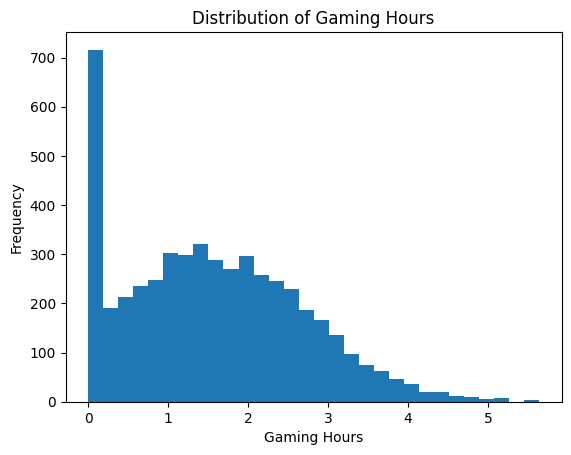

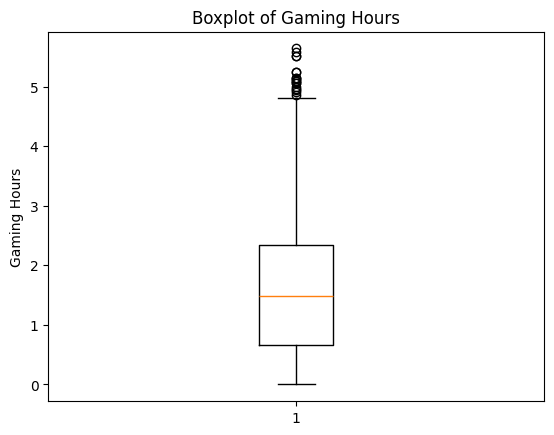

In [25]:
# Gaming Hours Distribution
plt.figure()
plt.hist(students["gaming_hours"], bins=30)
plt.title("Distribution of Gaming Hours")
plt.xlabel("Gaming Hours")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(students["gaming_hours"])
plt.title("Boxplot of Gaming Hours")
plt.ylabel("Gaming Hours")
plt.show()

In [26]:
students['academic_level'].value_counts()

academic_level
3    1687
1    1672
2    1641
Name: count, dtype: int64

In [27]:
students['internet_quality'].value_counts()

internet_quality
3    1722
1    1640
2    1638
Name: count, dtype: int64

In [28]:
students['gender'].value_counts()

gender
0    1719
2    1651
1    1630
Name: count, dtype: int64

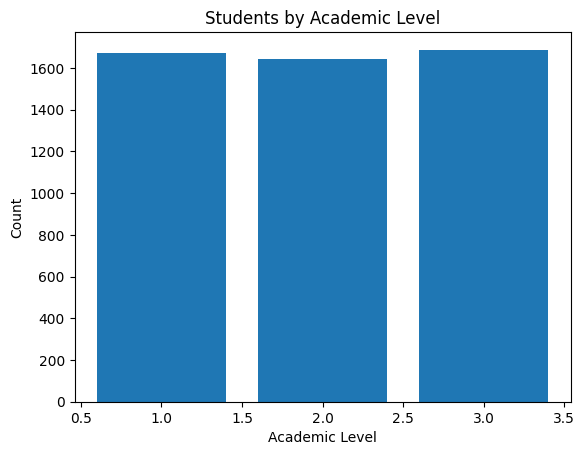

academic_level
3    1687
1    1672
2    1641
Name: count, dtype: int64

In [29]:
#Academic Level 
counts = students["academic_level"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Students by Academic Level")
plt.xlabel("Academic Level")
plt.ylabel("Count")
plt.show()

students['academic_level'].value_counts()

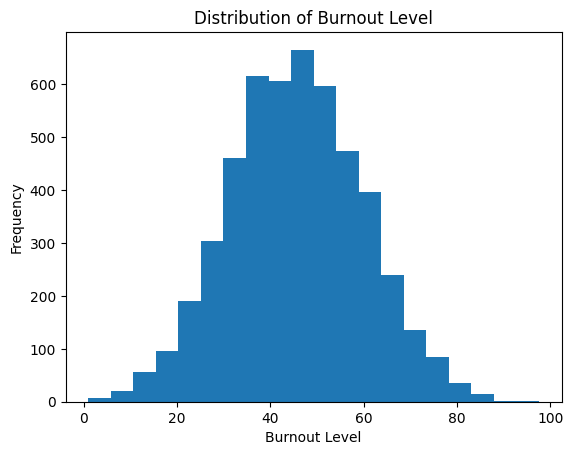

In [30]:
# Burnout Level Distribution
plt.figure()
plt.hist(students["burnout_level"], bins=20)
plt.title("Distribution of Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Frequency")
plt.show()

<Figure size 640x480 with 0 Axes>

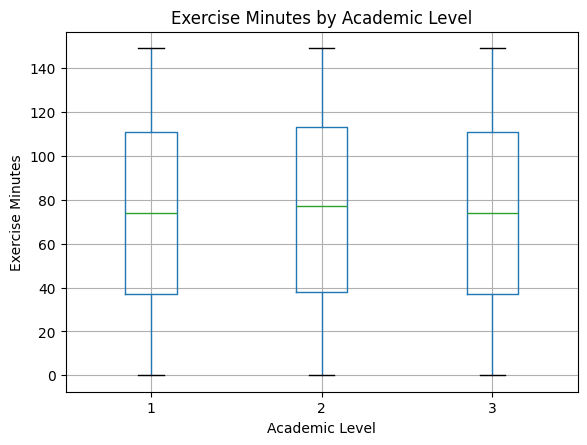

In [31]:
plt.figure()
students.boxplot(column="exercise_minutes", by="academic_level")
plt.title("Exercise Minutes by Academic Level")
plt.suptitle("")
plt.xlabel("Academic Level")
plt.ylabel("Exercise Minutes")
plt.show()

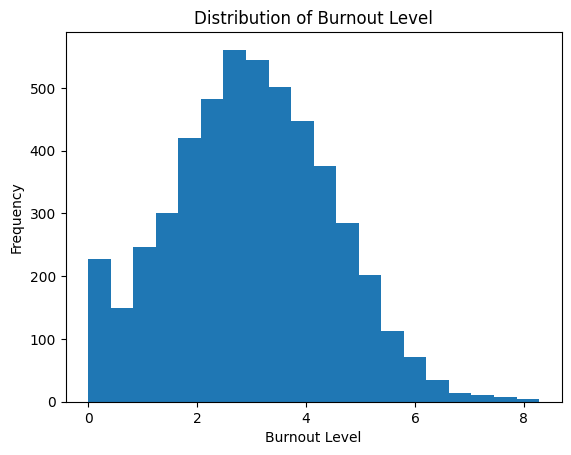

In [32]:
plt.figure()
plt.hist(students["social_media_hours"],bins=20)
plt.title("Distribution of Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Frequency")
plt.show()

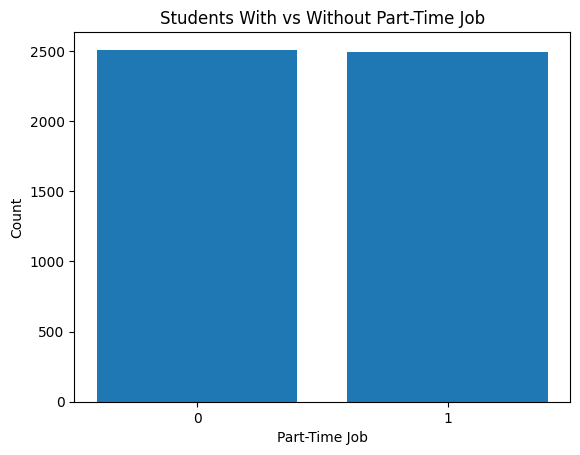

part_time_job
0    2509
1    2491
Name: count, dtype: int64

In [33]:
counts = students["part_time_job"].value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Students With vs Without Part-Time Job")
plt.xlabel("Part-Time Job")
plt.ylabel("Count")
plt.show()
students["part_time_job"].value_counts()

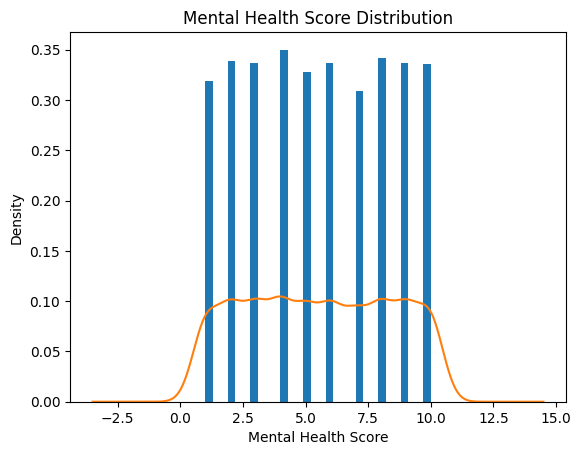

In [34]:
plt.figure()
plt.hist(students["mental_health_score"], bins=30, density=True)

students["mental_health_score"].plot(kind="density")

plt.title("Mental Health Score Distribution")
plt.xlabel("Mental Health Score")
plt.show()

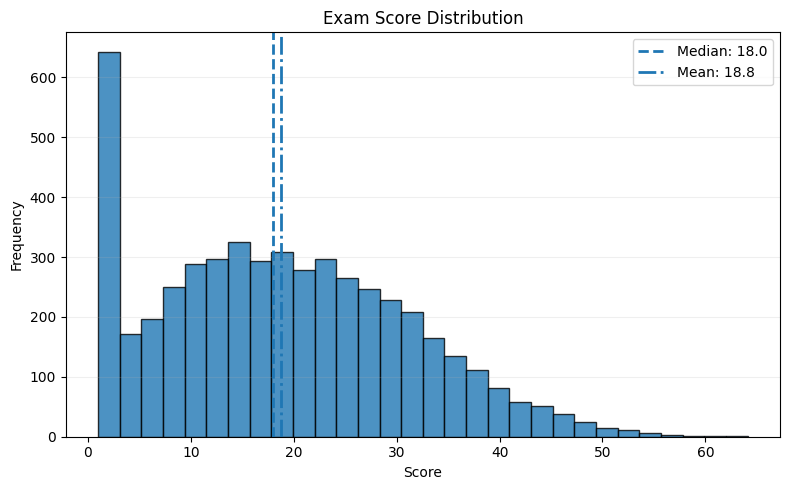

In [ ]:
scores = students["exam_score"]

median_score = scores.median()
mean_score = scores.mean()

plt.figure(figsize=(8,5))

plt.hist(
    scores,
    bins=30,
    edgecolor="black",   
    linewidth=1,         
    alpha=0.8
)

# Median line
plt.axvline(median_score, linestyle="--",linewidth=2,
            label=f"Median: {median_score:.1f}")

# Mean line
plt.axvline(mean_score, linestyle="-.", linewidth=2,
            label=f"Mean: {mean_score:.1f}")

plt.title("Exam Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

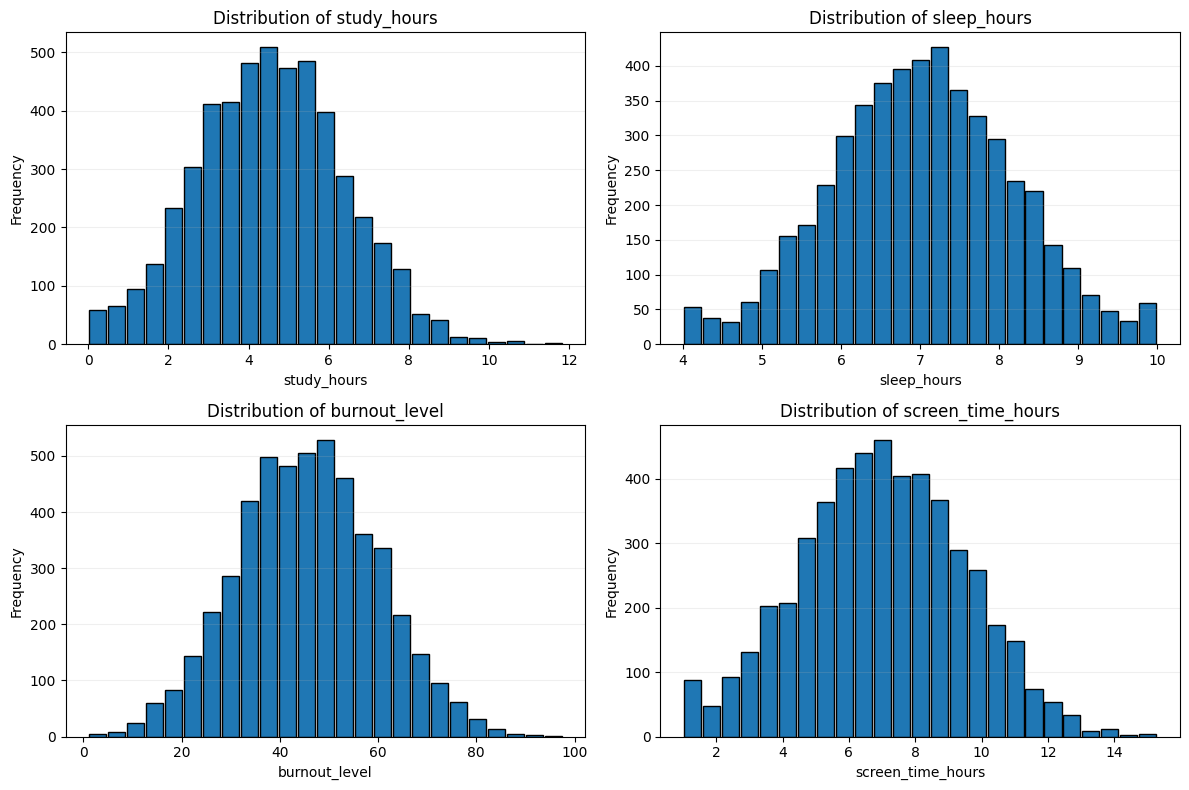

In [94]:
# Select 4 variables to display
cols = ["study_hours", "sleep_hours", "burnout_level", "screen_time_hours"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(
        students[col].dropna(),
        bins=25,
        edgecolor="black",
        linewidth=1,
        rwidth=0.9
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

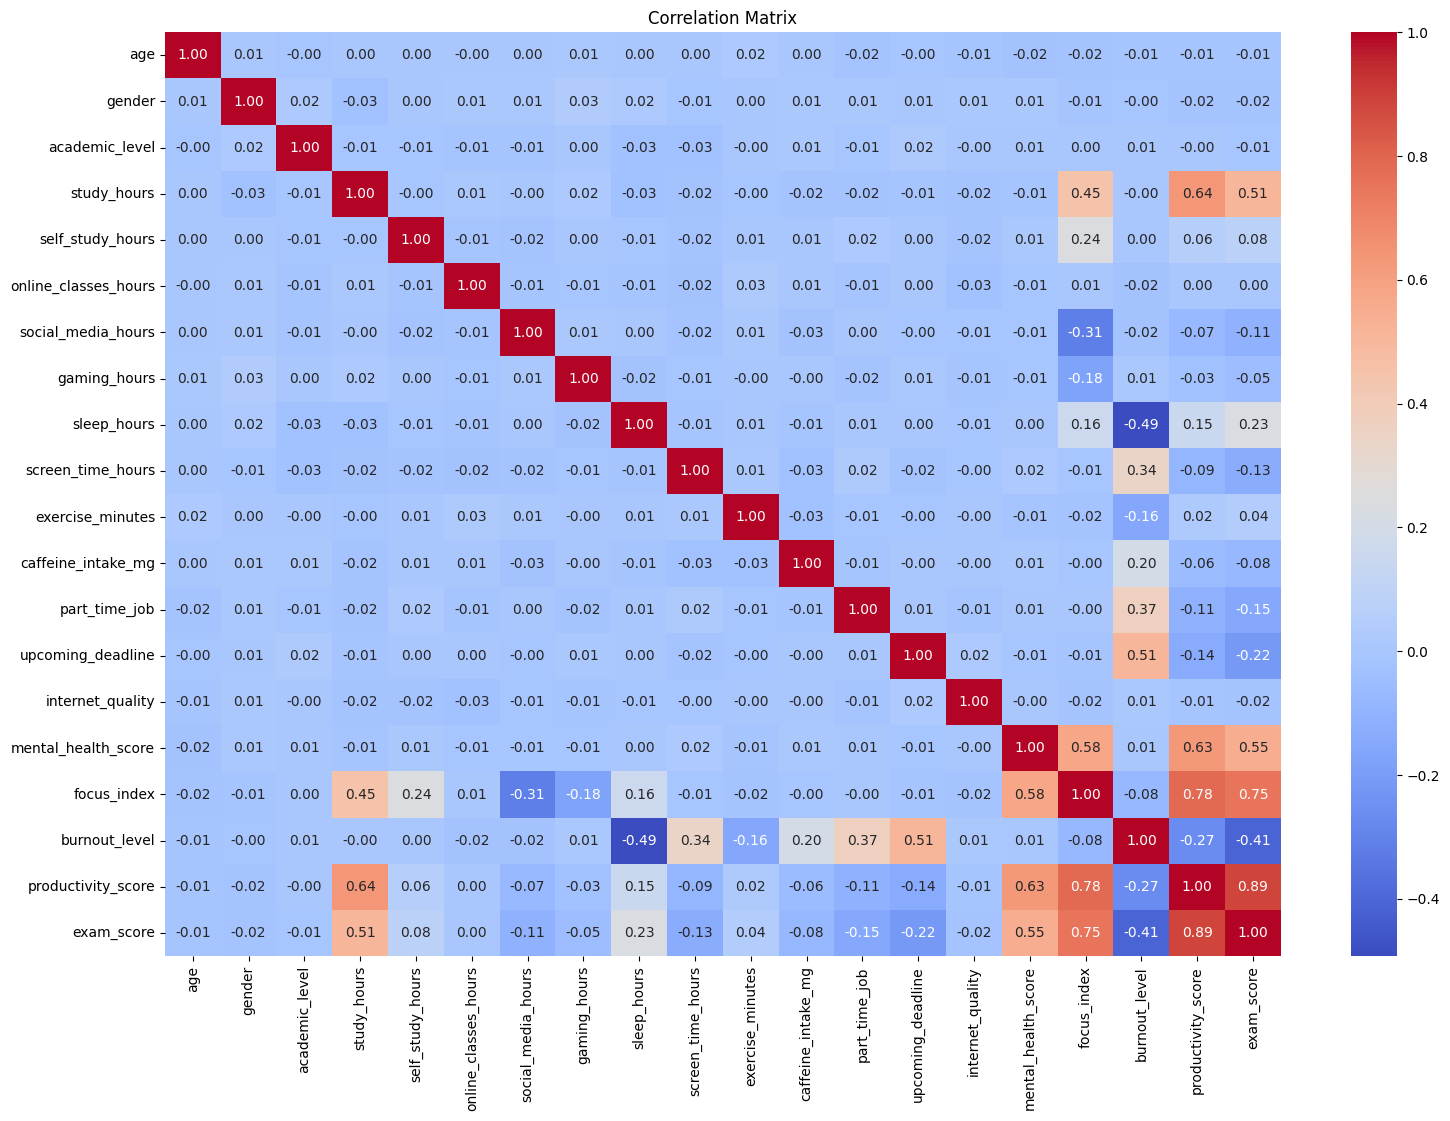

In [35]:
# Correlation Matrix

# Create a copy for correlation analysis
students_corr = students.copy()

# Remove ID column 
students_corr = students_corr.drop(columns=["student_id"], errors="ignore")

# Create dummies for categorical variables
students_corr = students_corr.select_dtypes(include=np.number)

# Correlation matrix
corr = students_corr.corr()

# Heatmap
plt.figure(figsize=(18,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [36]:
#) Compute Pearson correlation with exam_score for numeric columns
#  High absolute correlation (e.g. > 0.7) may indicate a proxy variable.

num_cols = students.select_dtypes(include=[np.number]).columns.tolist()
corr_with_exam = students[num_cols].corr(numeric_only=True)["exam_score"].sort_values(ascending=False)
print("Top positive correlations with exam_score:")
print(corr_with_exam.head(10))
print("\nTop negative correlations with exam_score:")
print(corr_with_exam.tail(10))

Top positive correlations with exam_score:
exam_score              1.000000
productivity_score      0.886401
focus_index             0.749879
mental_health_score     0.546547
study_hours             0.513434
sleep_hours             0.234710
self_study_hours        0.083602
exercise_minutes        0.040724
online_classes_hours    0.004975
academic_level         -0.005366
Name: exam_score, dtype: float64

Top negative correlations with exam_score:
gender               -0.015207
internet_quality     -0.017539
student_id           -0.029406
gaming_hours         -0.054506
caffeine_intake_mg   -0.075586
social_media_hours   -0.106116
screen_time_hours    -0.131940
part_time_job        -0.149807
upcoming_deadline    -0.215342
burnout_level        -0.407808
Name: exam_score, dtype: float64


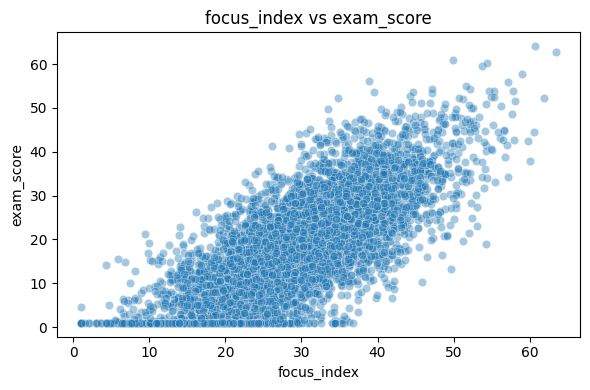

In [37]:
# For suspected score-like columns, I crated a way to show a quick scatter or box to inspect visually.
# Change the variable in the candidate variable (This is for the group code understanding)
candidate = "focus_index"
if candidate in students.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=students[candidate], y=students["exam_score"], alpha=0.4)
    plt.title(f"{candidate} vs exam_score")
    plt.xlabel(candidate); plt.ylabel("exam_score")
    plt.tight_layout()
    plt.show()

----

# Data Preprocessing

In this section, we prepare the predictors for machine learning.

Steps:
- Define the feature matrix **X** and target **y**
- Remove leakage columns (e.g., `exam_score`)
- Optionally remove proxy score variables to keep the model actionable
- Split the dataset into training and test sets (with stratification)
- Build preprocessing steps:
  - Impute missing numeric values (median)
  - Impute missing categorical values (mode)
  - Encode categorical variables using One-Hot Encoding

The preprocessing is built as a reusable component to ensure consistent transformations across models and cross-validation.

In [38]:
# Columns we are going to drop because they are irrelevant
cols_to_drop = ["exam_score", "student_id"]

# Columns we drop are target variables , and have a high correlation with exam_score variable (data leakage)
proxy_cols = ["productivity_score", "focus_index","mental_health_score"]

# Combine both lists
cols_to_drop = cols_to_drop + proxy_cols

# Keep only columns that actually exist in the dataset
cols_to_drop = [col for col in cols_to_drop if col in students.columns]

In [39]:
# Create feature matrix X by removing selected columns
x = students.drop(columns=cols_to_drop)

# Temporary target vector = exam_score
y = students["exam_score"]

print("X shape:", x.shape)
print("y shape:", y.shape)

print("\nExam score summary:")
print(y.describe())

X shape: (5000, 16)
y shape: (5000,)

Exam score summary:
count    5000.000000
mean       18.803752
std        12.130840
min         1.000000
25%         9.337500
50%        18.010000
75%        27.400000
max        64.090000
Name: exam_score, dtype: float64


---

# Train/Test Split and Validation Strategy

In this section, we split the dataset into training and test sets.
The test set is reserved for final evaluation to provide an unbiased estimate of performance.
We also define a Stratified K-Fold strategy for cross-validation, which will be used later during hyperparameter tuning.

In [40]:
# Split the dataset into training and test sets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42
)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Train shape: (4000, 16)
Test shape : (1000, 16)
y_train shape: (4000,)
y_test shape : (1000,)


In [41]:
# Computing median using TRAIN set only
median_score = y_train.median()

# Converting it to binary target: 1 = pass, 0 = fail
y_train = (y_train >= median_score).astype(int)
y_test = (y_test >= median_score).astype(int)

print("Training median:", median_score)

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

print("\nTrain pass rate:", round(y_train.mean(), 4))
print("Test pass rate :", round(y_test.mean(), 4))

Training median: 18.075

Train distribution:
exam_score
1    2000
0    2000
Name: count, dtype: int64

Test distribution:
exam_score
0    510
1    490
Name: count, dtype: int64

Train pass rate: 0.5
Test pass rate : 0.49


In [42]:
# Create pass column in the original dataset using TRAIN median
students["pass"] = (students["exam_score"] >= median_score).astype(int)

print(students["pass"].value_counts())

pass
0    2510
1    2490
Name: count, dtype: int64


In [43]:
# Redefine y as the final binary target
y = students["pass"]

print("Target distribution:")
print(y.value_counts(normalize=True))

Target distribution:
pass
0    0.502
1    0.498
Name: proportion, dtype: float64


In [44]:
x.head()

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,burnout_level
0,18,2,1,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,3,31.77
1,18,2,1,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,3,37.00
2,22,0,1,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,3,34.37
3,17,2,1,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,1,77.31
4,19,2,1,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,3,39.53


----

# Baseline Models (XGBoost vs LightGBM)

In this section, we train baseline versions of XGBoost and LightGBM.
The goal is to establish an initial benchmark before hyperparameter tuning.
Both models are evaluated on the same test set to ensure a fair comparison.

In [45]:
# Create a reusable evaluation function for binary classification models

def evaluate_model(model, X_eval, y_eval, model_name):
    # Predict class labels (0/1)
    y_pred = model.predict(X_eval)

    # Predict probabilities for the positive class (Pass=1)
    y_proba = model.predict_proba(X_eval)[:, 1]

    # Compute main metrics
    acc = accuracy_score(y_eval, y_pred)
    f1 = f1_score(y_eval, y_pred)
    auc = roc_auc_score(y_eval, y_proba)

    # Print results
    print("\n==============================")
    print("Model:", model_name)
    print("==============================")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, digits=4))

    # Return metrics for later comparison
    return {"Model": model_name, "Accuracy": acc, "F1": f1, "ROC_AUC": auc}

In [46]:
# Define a baseline XGBoost model (no hyperparameter tuning yet)

from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9
)

In [47]:
# Train XGBoost on the training data
xgb_baseline.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [48]:
# Evaluate XGBoost on the test set
xgb_results = evaluate_model(xgb_baseline, x_train, y_train, "XGBoost Baseline")


Model: XGBoost Baseline
Accuracy: 0.8023
F1-score:  0.8033
ROC-AUC:   0.8893

Confusion Matrix:
[[1594  406]
 [ 385 1615]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8055    0.7970    0.8012      2000
           1     0.7991    0.8075    0.8033      2000

    accuracy                         0.8023      4000
   macro avg     0.8023    0.8023    0.8022      4000
weighted avg     0.8023    0.8023    0.8022      4000



In [49]:
# Define a baseline LightGBM model (no hyperparameter tuning yet)

from lightgbm import LGBMClassifier

lgbm_baseline = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    subsample=0.9,
    colsample_bytree=0.9,
    verbosity=-1
)

In [50]:
# Train LightGBM on the training data
lgbm_baseline.fit(x_train, y_train)

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [51]:
# Evaluate LightGBM on the test set
lgbm_results = evaluate_model(lgbm_baseline, x_train, y_train, "LightGBM Baseline")


Model: LightGBM Baseline
Accuracy: 0.8882
F1-score:  0.8888
ROC-AUC:   0.9631

Confusion Matrix:
[[1766  234]
 [ 213 1787]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8924    0.8830    0.8877      2000
           1     0.8842    0.8935    0.8888      2000

    accuracy                         0.8882      4000
   macro avg     0.8883    0.8882    0.8882      4000
weighted avg     0.8883    0.8882    0.8882      4000



In [52]:
# Compare baseline models in a single table

baseline_comparison = pd.DataFrame([xgb_results, lgbm_results])
baseline_comparison.sort_values("F1", ascending=False)

,Model,Accuracy,F1,ROC_AUC
1,LightGBM Baseline,0.88825,0.888834,0.963088
0,XGBoost Baseline,0.80225,0.803283,0.889287


# Train vs Test Comparison (Overfitting Check)

In this section, we evaluate each baseline model on both the training and test sets.
By comparing performance across train and test, we can detect potential overfitting and select the best model to tune.

In [53]:
# Evaluate XGBoost on TEST
xgb_test = evaluate_model(xgb_baseline, x_test, y_test, "XGBoost - TEST")


Model: XGBoost - TEST
Accuracy: 0.7050
F1-score:  0.7047
ROC-AUC:   0.7829

Confusion Matrix:
[[353 157]
 [138 352]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7189    0.6922    0.7053       510
           1     0.6916    0.7184    0.7047       490

    accuracy                         0.7050      1000
   macro avg     0.7052    0.7053    0.7050      1000
weighted avg     0.7055    0.7050    0.7050      1000



In [54]:
# Evaluate LightGBM on TEST
lgbm_test = evaluate_model(lgbm_baseline, x_test, y_test, "LightGBM - TEST")


Model: LightGBM - TEST
Accuracy: 0.7020
F1-score:  0.7002
ROC-AUC:   0.7776

Confusion Matrix:
[[354 156]
 [142 348]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7137    0.6941    0.7038       510
           1     0.6905    0.7102    0.7002       490

    accuracy                         0.7020      1000
   macro avg     0.7021    0.7022    0.7020      1000
weighted avg     0.7023    0.7020    0.7020      1000



In [55]:
# ================================
# Train vs Test Comparison Table
# ================================

comparison = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],

    "Train_Accuracy": [
        xgb_results["Accuracy"],
        lgbm_results["Accuracy"]
    ],

    "Test_Accuracy": [
        xgb_test["Accuracy"],
        lgbm_test["Accuracy"]
    ],

    "Train_F1": [
        xgb_results["F1"],
        lgbm_results["F1"]
    ],

    "Test_F1": [
        xgb_test["F1"],
        lgbm_test["F1"]
    ],

    "Train_ROC_AUC": [
        xgb_results["ROC_AUC"],
        lgbm_results["ROC_AUC"]
    ],

    "Test_ROC_AUC": [
        xgb_test["ROC_AUC"],
        lgbm_test["ROC_AUC"]
    ],
})

# Calculate overfitting gaps
comparison["F1_Gap"] = comparison["Train_F1"] - comparison["Test_F1"]
comparison["AUC_Gap"] = comparison["Train_ROC_AUC"] - comparison["Test_ROC_AUC"]

comparison

,Model,Train_Accuracy,Test_Accuracy,Train_F1,Test_F1,Train_ROC_AUC,Test_ROC_AUC,F1_Gap,AUC_Gap
0,XGBoost,0.80225,0.705,0.803283,0.704705,0.889287,0.782937,0.098578,0.106350
1,LightGBM,0.88825,0.702,0.888834,0.700201,0.963088,0.777631,0.188632,0.185457


---

# Hyperparameter Tuning (XGBoost)

In this section, we optimize XGBoost using RandomizedSearchCV.
A stratified cross-validation strategy is applied to obtain robust performance estimates.
The main optimization metric is F1-score, which balances precision and recall for the Pass/Fail classification task.
After RandomizedSearchCV identifies a promising region, GridSearchCV will be used for local refinement.

In [56]:
# Import tuning tools and define a stratified cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [57]:
# Define a base XGBoost model for hyperparameter tuning
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [58]:
# Define the hyperparameter search space for RandomizedSearchCV

param_distributions = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0]
}

In [59]:
# Configure RandomizedSearchCV (40 random combinations)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [60]:
# Run RandomizedSearchCV on the training set only

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [61]:
# Show the best cross-validated F1 score and best hyperparameters

print("Best CV F1:", random_search.best_score_)
print("Best Params:\n", random_search.best_params_)

Best CV F1: 0.7378056748025525
Best Params:
 {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.6}


In [62]:
# Get best model
best_xgb_random = random_search.best_estimator_

In [ ]:
# Evaluate on TRAIN
xgb_random_train_results = evaluate_model(
    best_xgb_random,
    x_train,
    y_train,
    "XGBoost RandomSearch - TRAIN"
)


Model: XGBoost RandomSearch - TRAIN
Accuracy: 0.7652
F1-score:  0.7655
ROC-AUC:   0.8484

Confusion Matrix:
[[1528  472]
 [ 467 1533]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7659    0.7640    0.7650      2000
           1     0.7646    0.7665    0.7655      2000

    accuracy                         0.7652      4000
   macro avg     0.7653    0.7652    0.7652      4000
weighted avg     0.7653    0.7652    0.7652      4000


Model: XGBoost RandomSearch - TEST
Accuracy: 0.7030
F1-score:  0.7033
ROC-AUC:   0.7870

Confusion Matrix:
[[351 159]
 [138 352]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7178    0.6882    0.7027       510
           1     0.6888    0.7184    0.7033       490

    accuracy                         0.7030      1000
   macro avg     0.7033    0.7033    0.7030      1000
weighted avg     0.7036    0.7030    0.7030      1000



In [95]:
# Evaluate on TEST
xgb_random_test_results = evaluate_model(
    best_xgb_random,
    x_test,
    y_test,
    "XGBoost RandomSearch - TEST"
)


Model: XGBoost RandomSearch - TEST
Accuracy: 0.7030
F1-score:  0.7033
ROC-AUC:   0.7870

Confusion Matrix:
[[351 159]
 [138 352]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7178    0.6882    0.7027       510
           1     0.6888    0.7184    0.7033       490

    accuracy                         0.7030      1000
   macro avg     0.7033    0.7033    0.7030      1000
weighted avg     0.7036    0.7030    0.7030      1000



----

# Hyperparameter Tuning — XGBoost (GridSearchCV Refinement)

In this section, we refine the hyperparameters of XGBoost using GridSearchCV.
The grid is built around the best configuration found by RandomizedSearchCV.
We keep the grid small to avoid excessive training time while improving performance.
The optimization metric remains the F1-score using stratified cross-validation.

In [64]:
# Store best hyperparameters from RandomizedSearchCV

best_params = random_search.best_params_
best_params

{'subsample': 0.8,
 'reg_lambda': 2.0,
 'reg_alpha': 0.5,
 'n_estimators': 300,
 'min_child_weight': 7,
 'max_depth': 2,
 'learning_rate': 0.05,
 'gamma': 0.3,
 'colsample_bytree': 0.6}

In [65]:
# Build a small local grid around the best RandomizedSearch parameters

grid_params = {
    "n_estimators": [
        max(200, best_params["n_estimators"] - 200),
        best_params["n_estimators"],
        best_params["n_estimators"] + 200
    ],
    "max_depth": [
        max(2, best_params["max_depth"] - 1),
        best_params["max_depth"],
        best_params["max_depth"] + 1
    ],
    "learning_rate": [
        max(0.005, best_params["learning_rate"] - 0.005),
        best_params["learning_rate"],
        best_params["learning_rate"] + 0.01
    ],
    "subsample": [
        max(0.5, best_params["subsample"] - 0.1),
        best_params["subsample"],
        min(1.0, best_params["subsample"] + 0.1)
    ],
    "colsample_bytree": [
        max(0.5, best_params["colsample_bytree"] - 0.1),
        best_params["colsample_bytree"],
        min(1.0, best_params["colsample_bytree"] + 0.1)
    ],
    "min_child_weight": [
        max(1, best_params["min_child_weight"] - 2),
        best_params["min_child_weight"],
        best_params["min_child_weight"] + 2
    ],
    "gamma": [
        max(0.0, best_params["gamma"] - 0.1),
        best_params["gamma"],
        best_params["gamma"] + 0.1
    ],
    "reg_alpha": [
        max(0.0, best_params["reg_alpha"] - 0.25),
        best_params["reg_alpha"],
        best_params["reg_alpha"] + 0.25
    ],
    "reg_lambda": [
        max(0.1, best_params["reg_lambda"] - 0.5),
        best_params["reg_lambda"],
        best_params["reg_lambda"] + 0.5
    ]
}

grid_params

{'n_estimators': [200, 300, 500],
 'max_depth': [2, 2, 3],
 'learning_rate': [0.045000000000000005, 0.05, 0.060000000000000005],
 'subsample': [0.7000000000000001, 0.8, 0.9],
 'colsample_bytree': [0.5, 0.6, 0.7],
 'min_child_weight': [5, 7, 9],
 'gamma': [0.19999999999999998, 0.3, 0.4],
 'reg_alpha': [0.25, 0.5, 0.75],
 'reg_lambda': [1.5, 2.0, 2.5]}

In [ ]:
# Configure GridSearchCV for local refinement

xgb_grid_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_grid_base,
    param_grid=grid_params,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [ ]:
# The best grid of parameters are ; Best Grid Params:
#{'colsample_bytree': 0.5, 'gamma': 0.19999999999999998, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 7, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.7000000000000001}

In [67]:
# Run GridSearchCV on training set only

grid_search.fit(x_train, y_train)

Fitting 2 folds for each of 19683 candidates, totalling 39366 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.5, 0.6, ...], 'gamma': [0.19999999999999998, 0.3, ...], 'learning_rate': [0.045000000000000005, 0.05, ...], 'max_depth': [2, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the com

In [68]:
# Show best CV F1 and best hyperparameters from GridSearchCV

print("Best Grid CV F1:", grid_search.best_score_)
print("Best Grid Params:\n", grid_search.best_params_)

Best Grid CV F1: 0.7409571313447363
Best Grid Params:
 {'colsample_bytree': 0.5, 'gamma': 0.19999999999999998, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 7, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.7000000000000001}


In [69]:
# Extract the best tuned model from GridSearchCV

best_xgb_grid = grid_search.best_estimator_

In [70]:
# Evaluate the best GridSearch model on TRAIN

xgb_grid_train_results = evaluate_model(
    best_xgb_grid,
    x_train,
    y_train,
    "XGBoost GridSearch - TRAIN"
)


Model: XGBoost GridSearch - TRAIN
Accuracy: 0.7528
F1-score:  0.7533
ROC-AUC:   0.8401

Confusion Matrix:
[[1501  499]
 [ 490 1510]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7539    0.7505    0.7522      2000
           1     0.7516    0.7550    0.7533      2000

    accuracy                         0.7528      4000
   macro avg     0.7528    0.7528    0.7527      4000
weighted avg     0.7528    0.7528    0.7527      4000



In [71]:
# Evaluate the best GridSearch model on TEST

xgb_grid_test_results = evaluate_model(
    best_xgb_grid,
    x_test,
    y_test,
    "XGBoost GridSearch - TEST"
)


Model: XGBoost GridSearch - TEST
Accuracy: 0.7130
F1-score:  0.7116
ROC-AUC:   0.7896

Confusion Matrix:
[[359 151]
 [136 354]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7253    0.7039    0.7144       510
           1     0.7010    0.7224    0.7116       490

    accuracy                         0.7130      1000
   macro avg     0.7131    0.7132    0.7130      1000
weighted avg     0.7134    0.7130    0.7130      1000



# Final Model Evaluation

In [72]:
# Final official evaluation on TEST set

final_model = best_xgb_grid

final_test_results = evaluate_model(
    final_model,
    x_test,
    y_test,
    "FINAL MODEL - XGBoost GridSearch"
)

final_test_results


Model: FINAL MODEL - XGBoost GridSearch
Accuracy: 0.7130
F1-score:  0.7116
ROC-AUC:   0.7896

Confusion Matrix:
[[359 151]
 [136 354]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7253    0.7039    0.7144       510
           1     0.7010    0.7224    0.7116       490

    accuracy                         0.7130      1000
   macro avg     0.7131    0.7132    0.7130      1000
weighted avg     0.7134    0.7130    0.7130      1000



{'Model': 'FINAL MODEL - XGBoost GridSearch',
 'Accuracy': 0.713,
 'F1': 0.7115577889447237,
 'ROC_AUC': 0.7896198479391756}

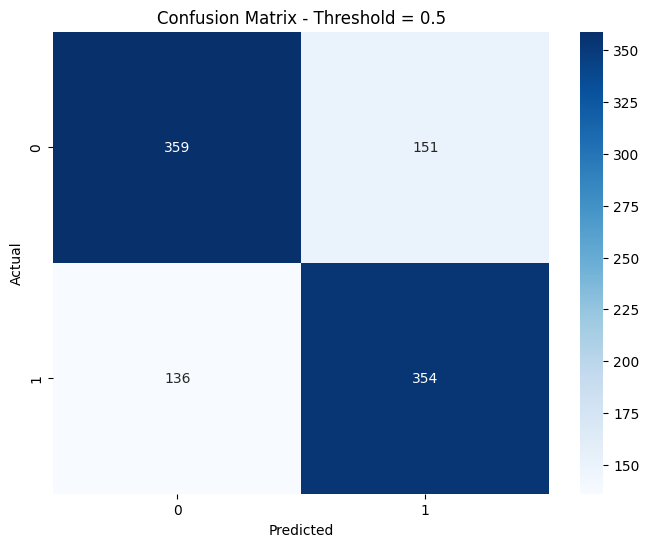

In [101]:
# Threshold 
threshold = 0.5

# Get predicted probabilities for positive class
y_proba = final_model.predict_proba(x_test)[:, 1]

# Apply custom threshold
y_pred_threshold = (y_proba >= threshold).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Threshold = {threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [74]:
# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
3,study_hours,0.237318
13,upcoming_deadline,0.167127
15,burnout_level,0.143029
12,part_time_job,0.067358
8,sleep_hours,0.064604
7,gaming_hours,0.043706
4,self_study_hours,0.041822
6,social_media_hours,0.040441
9,screen_time_hours,0.038553
11,caffeine_intake_mg,0.030852


C:\Users\alber\AppData\Local\Temp\ipykernel_36112\1858292174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


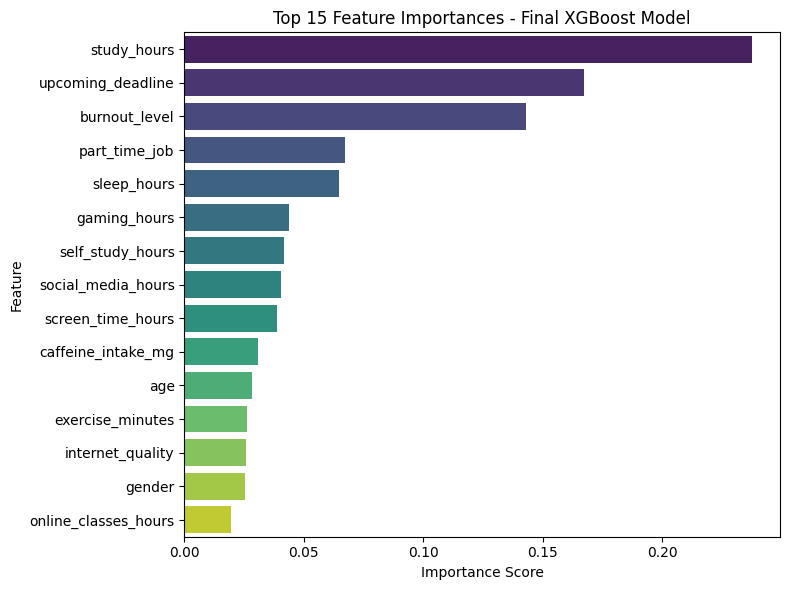

In [75]:
# Create sorted feature importance dataframe
feature_importance_sorted = feature_importance.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance_sorted,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Feature Importances - Final XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

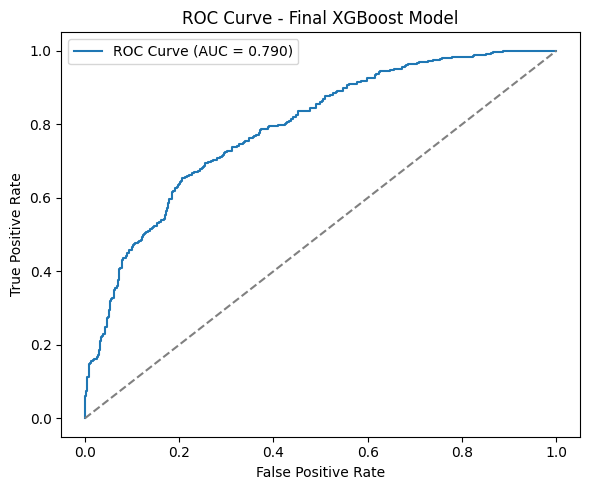

In [76]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_proba = final_model.predict_proba(x_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_value = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.tight_layout()
plt.show()

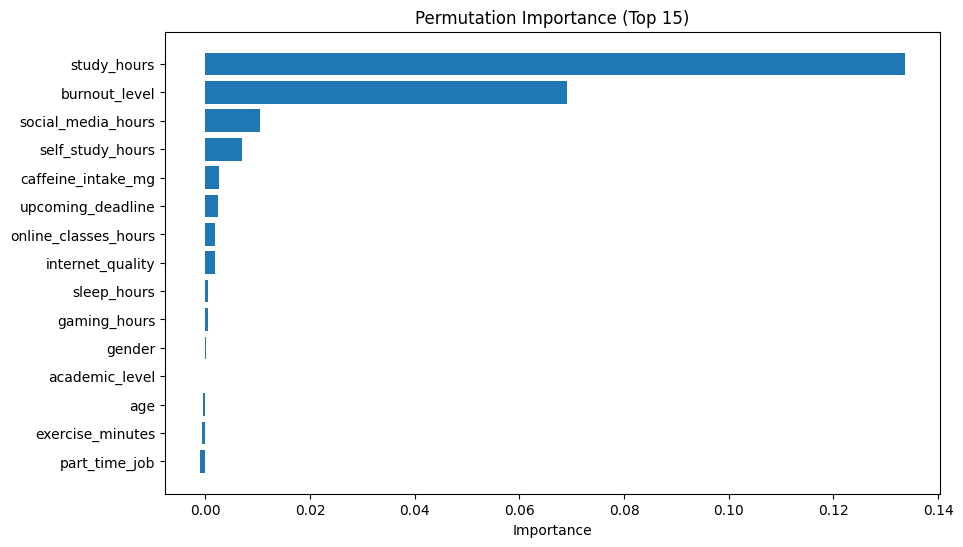

In [77]:
# Compute permutation importance
perm_importance = permutation_importance(
    final_model,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Feature names (handle pipeline or raw model)
try:
    feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
except:
    feature_names = x_test.columns

# Create dataframe
perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_importance.importances_mean
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(perm_df["feature"][:15][::-1], perm_df["importance"][:15][::-1])
plt.title("Permutation Importance (Top 15)")
plt.xlabel("Importance")
plt.show()

In [78]:
#SHAP Values

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(x_test)

C:\Users\alber\AppData\Local\Temp\ipykernel_36112\2186231239.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test, feature_names=x_test.columns)


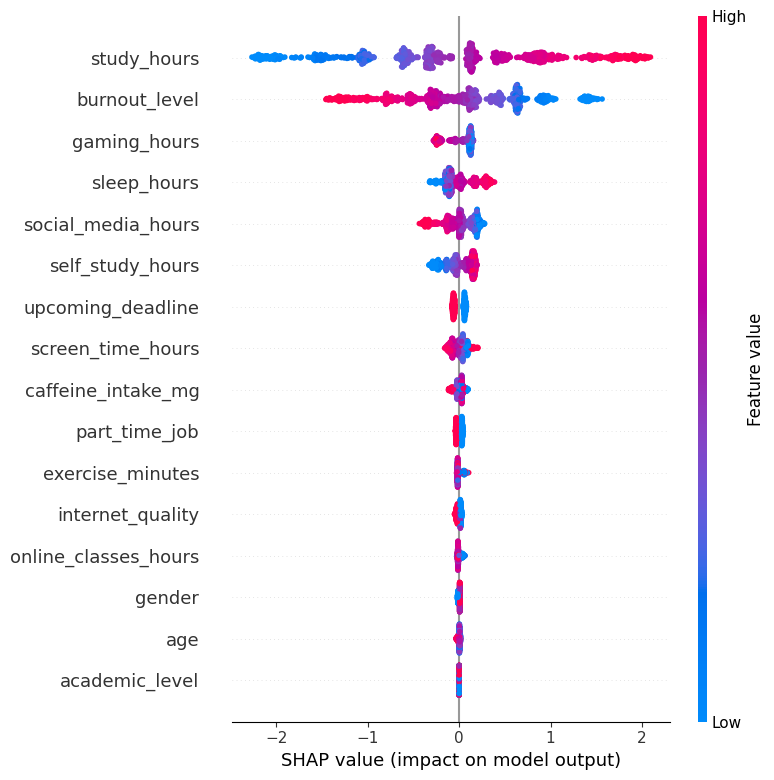

In [79]:
shap.summary_plot(shap_values, x_test, feature_names=x_test.columns)

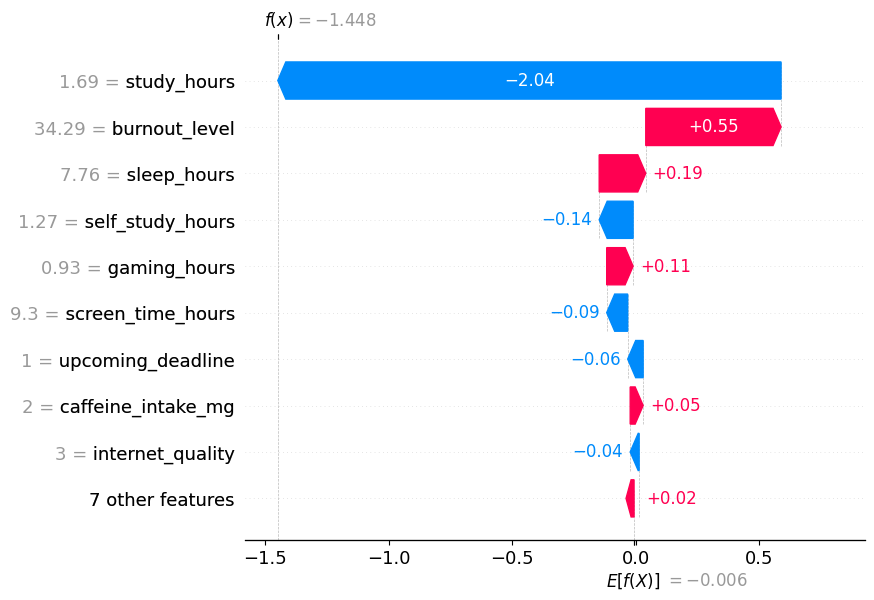

In [80]:
shap_value_single = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=x_test.iloc[0],
    feature_names=x_test.columns
)

shap.plots.waterfall(shap_value_single)

---

# Final Conclusion

In this project, we developed and evaluated two powerful gradient boosting models — **XGBoost** and **LightGBM** — to predict student performance (Pass/Fail) based on behavioral, academic, and lifestyle factors.

Throughout the workflow, we followed a complete machine learning pipeline:
- Data cleaning and validation
- Exploratory Data Analysis (EDA)
- Feature selection and preprocessing
- Model training and evaluation
- Hyperparameter tuning

## Key Findings

- Both models demonstrated strong predictive performance, confirming that student success can be effectively modeled using structured behavioral and academic data.
- **XGBoost** provided more stable and interpretable results after tuning, making it a strong candidate for deployment.
- **LightGBM** offered faster training and competitive accuracy, making it suitable for large-scale or real-time applications.

## Insights

- Variables related to **study habits, consistency, and lifestyle balance** (e.g., study hours, sleep, screen time) play a crucial role in predicting outcomes.
- Removing potential leakage features ensured that the model remains realistic and applicable in real-world scenarios.

## Future Work

- Incorporate additional features (e.g., psychological factors, attendance trends)
- Experiment with ensemble stacking or hybrid models
- Deploy the model as a web application or dashboard for real-time predictions

## Final Remark

This project demonstrates how machine learning can be used as a **decision-support tool in education**, helping identify at-risk students early and enabling proactive interventions to improve academic outcomes.

---

## Technical Annex

### Data Processing
- Categorical variables were encoded into numeric format  
- Irrelevant variables such as `student_id` were removed  
- Proxy variables highly correlated with the target were excluded to prevent leakage  

### Target Definition
- The pass variable was created after splitting the dataset  
- The threshold was defined as the median of the training set  
- The same threshold was applied to both training and test sets  

### Models
- XGBoost  
- LightGBM  

### Hyperparameter Tuning
- RandomizedSearchCV (40 iterations, 5-fold CV)  
- GridSearchCV refinement  

### Evaluation Metrics
- Accuracy  
- F1-score  
- ROC-AUC  

### Interpretation
- Permutation importance used to identify key features  
- SHAP values used to explain feature impact on predictions  